In [1]:
from pprint import pprint

import qlib
import pandas as pd

from qlib.utils.time import Freq
from qlib.utils import flatten_dict
from qlib.contrib.evaluate import backtest_daily
from qlib.contrib.evaluate import risk_analysis
from qlib.contrib.strategy import TopkDropoutStrategy

from qlib.contrib.data.loader import Alpha158DL
from qlib.data.dataset.loader import QlibDataLoader

In [ ]:
data_path = "~/.qlib/qlib_data/cn_data"
region = "cn"

instruments = "csi300"
start_time = "2018-01-01"
end_time = "2022-12-31"
    
qlib.init(provider_uri=data_path, region=region)
data_loader = Alpha158DL()

df = data_loader.load(
    instruments=instruments, start_time=start_time, end_time=end_time
)
feature_df = df["feature"]
feature_df.head()

[1976200:MainThread](2025-10-09 13:38:05,225) INFO - qlib.Initialization - [config.py:420] - default_conf: client.
[1976200:MainThread](2025-10-09 13:38:05,229) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[1976200:MainThread](2025-10-09 13:38:05,230) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': PosixPath('/home/hluo/.qlib/qlib_data/cn_data')}


KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2018-01-02 SH600000    0.008723  0.013481  0.647058  0.003965  0.294122   
           SH600008    0.009709  0.017476  0.555560  0.003883  0.222218   
           SH600009   -0.013333  0.026667 -0.499997  0.007333  0.275002   
           SH600010    0.016260  0.024390  0.666667  0.004065  0.166668   
           SH600011    0.014563  0.022654  0.642857  0.004854  0.214287   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2018-01-02 SH600000    0.000793  0.058820  0.005551  0.411756  0.991352  ...   
           SH600008    0.003884  0.222222  0.009709  0.555563  0.990385  ...   
           SH600009    0.006000  0.225001 -0.014667 -0.549998  1.013513  ...   
           SH600010    0.004065  0.166665  0.016260  0.666664  0.984000  ...   
           SH600011    0.003236  0.142857  0.012945  0.571427  0.985646  ...   

                         VSUMN5   VSUMN10   VSUMN20   VSUMN30   VSUMN60  \
datetime   instrument                                                     
2018-01-02 SH600000    0.386506  0.388162  0.508938  0.531579  0.509718   
           SH600008    0.486630  0.431781  0.484230  0.486603  0.507665   
           SH600009    0.315800  0.428592  0.468054  0.550977  0.510013   
           SH600010    0.556868  0.456156  0.531977  0.488366  0.494931   
           SH600011    0.714064  0.510931  0.554335  0.498614  0.490070   

                         VSUMD5   VSUMD10   VSUMD20   VSUMD30   VSUMD60  
datetime   instrument                                                    
2018-01-02 SH600000    0.226988  0.223677 -0.017876 -0.063158 -0.019435  
           SH600008    0.026740  0.136438  0.031541  0.026794 -0.015329  
           SH600009    0.368400  0.142816  0.063893 -0.101953 -0.020027  
           SH600010   -0.113736  0.087688 -0.063954  0.023269  0.010138  
           SH600011   -0.428129 -0.021863 -0.108670  0.002772  0.019860  

[5 rows x 158 columns]

In [8]:
labels = ["Ref($close, -1)/$close - 1"]
label_names = ["LABEL"]

# Build config
data_loader_config = {"label": (labels, label_names)}

# Load data
label_data_loader = QlibDataLoader(config=data_loader_config)

label_df = label_data_loader.load(
    instruments=instruments, start_time=start_time, end_time=end_time
)['label']
label_df.head(20)

LABEL
datetime   instrument          
2018-01-02 SH600000   -0.004717
           SH600008         NaN
           SH600009   -0.007883
           SH600010    0.004000
           SH600011    0.007975
           SH600015    0.002195
           SH600016    0.007042
           SH600018    0.014793
           SH600019   -0.003348
           SH600021    0.008714
           SH600023    0.003724
           SH600028    0.015699
           SH600029    0.047368
           SH600030    0.009219
           SH600031   -0.001055
           SH600036    0.011816
           SH600038    0.011499
           SH600048   -0.012312
           SH600050    0.040373
           SH600061    0.010534

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

alpha = 0.5
feature_filled = feature_df.fillna(0)
label_filled = label_df.fillna(0)

all_dates = sorted(feature_filled.index.get_level_values(0).unique())
all_tickers = sorted(feature_filled.index.get_level_values(1).unique())

scaler = StandardScaler()
model = Ridge(alpha=alpha)

preds = []
coef_history = []

min_history = 30

# train on all days before this one
past_dates = all_dates[:min_history]
X_train = feature_filled.loc[past_dates].values
y_train = label_filled.loc[past_dates].values.flatten()

# normalize and fit
X_scaled = scaler.fit_transform(X_train)
model.fit(X_scaled, y_train)

# record coefficients (optional)
coef_history.append(model.coef_)


In [ ]:
model.coef_

array([-2.77345360e-04,  1.42738211e-03, -8.33411352e-04, -1.07095882e-04,
       -7.76464294e-04,  1.00848491e-04,  1.39905629e-03, -1.74048895e-04,
        2.42575348e-04,  8.24960042e-03, -2.37071840e-03,  3.62392254e-02,
        0.00000000e+00,  3.35200946e-03,  1.28190219e-03, -5.81181201e-04,
        9.99580137e-04,  6.64596620e-04,  2.22700108e-02,  4.94376849e-03,
        1.13780415e-02, -2.24170331e-02,  3.40133719e-02, -1.63849478e-03,
        2.66629481e-03, -3.01943999e-03, -9.23674088e-04,  1.49186165e-03,
        8.74737743e-03,  2.12641656e-02, -2.77543738e-02,  2.78196158e-03,
        4.66218218e-03,  3.55853372e-05,  3.95602328e-05,  2.36728665e-04,
       -3.51473194e-04,  6.95596682e-04,  3.82937980e-03,  2.72979424e-03,
       -3.95019688e-02,  1.94505081e-02, -3.34366458e-03,  3.58471163e-02,
        4.68352949e-03, -5.06894430e-03, -1.01656688e-03, -5.99618396e-03,
       -3.98008106e-03,  1.11660389e-02, -3.64583429e-05, -8.48206226e-03,
        8.00866354e-03, -

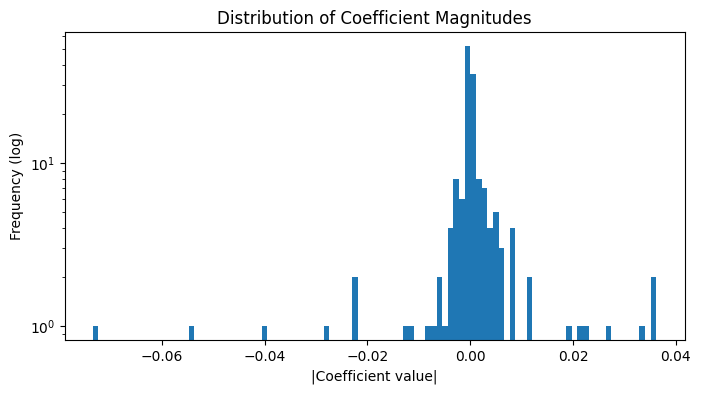

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(model.coef_, bins=100, log=True)
plt.xlabel("|Coefficient value|")
plt.ylabel("Frequency (log)")
plt.title("Distribution of Coefficient Magnitudes")
plt.show()
